<a href="https://colab.research.google.com/github/foultraengineer9/AI_Final_Project/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# English Word Complexity Classifier
This notebook implements a machine learning system (stacked ensemble with a deep learning + classical model) to classify English words into three CEFR difficulty tiers:

Tier 0 (Beginner): A1–A2
Tier 1 (Intermediate): B1–B2
Tier 2 (Advanced): C1–C2

## Improvements over pervious notebooks

*   *deprecated* **Semantic Space:** Contextual Sentence Transformer Embeddings (`all-MiniLM-L6-v2`).
*   **Psycholinguistic Norms:** Brysbaert Concreteness Ratings, Familiarity Ratings, and SUBTLEX-US Frequency.
*   **Linguistic Taxonomy:** Taxonomic depth and polysemy tracking via NLTK WordNet.
*   **Orthographic Metrics:** Consonant cluster density, character Shannon entropy, and academic affixes.
* **768D Transformer Space:** Migrated from MiniLM to the state-of-the-art `all-mpnet-base-v2` semantic encoder.

* **Expanded Feature Space (30D):** Added WordNet Hyponym counts, NLTK Lemmatization (derivation indicators), and Letter Diversity.

* **Label Smoothing (0.10):** Prevents overconfidence on boundary terms.

* **Triple-Stack Ensemble:** Blends Gradient Boosting (XGBoost), Bagging (Random Forest), and Representation Learning (Late Fusion MLP).

# Part 1: Initial Setup & Environment Config

In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 37.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip install syllables tensorflow tensorflow-keras

In [ ]:
import os
import re
import numpy as np
import pandas as pd
import nltk
import syllables
import matplotlib.pyplot as plt
import seaborn as sns
import spacy # Import spacy

import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.utils import to_categorical
from sentence_transformers import SentenceTransformer

# Download NLTK requirements
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.corpus import wordnet as wn
from nltk.stem import WordNetLemmatizer

embedding_model = SentenceTransformer("all-mpnet-base-v2")

try:
    nlp = spacy.load('en_core_web_sm')
    print("spaCy 'en_core_web_sm' model loaded successfully.")
except OSError:
    print("Downloading spaCy 'en_core_web_sm' model...")
    !python -m spacy download en_core_web_sm --quiet
    nlp = spacy.load('en_core_web_sm')
    print("spaCy 'en_core_web_sm' model downloaded and loaded.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

spaCy 'en_core_web_sm' model loaded successfully.


# Part 2: Feature Extraction Pipeline

This class incorporates psycholinguistic lookups and taxonomical WordNet queries into a single feature extraction state. This stateful class extracts traditional complexity features alongside advanced orthographic metrics, preserving the fitted scaler and cluster configurations across both training and inference.

In [ ]:
class WordComplexityFeaturePipeline:
    """
    Stateful complexity pipeline incorporating psycholinguistic norms,
    WordNet taxonomic depth/hyponyms, NLTK lemmatization, and 768D MPNet embeddings
    """
    def __init__(self, transformer_model, concreteness_df=None, n_clusters=6):
        self.transformer = transformer_model
        self.n_clusters = n_clusters
        self.frequency_dict = {}

        # Stateful modeling configurations
        self.scaler = StandardScaler()
        self.kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        self.lemmatizer = WordNetLemmatizer()
        self.is_fitted = False

        # Pillar 1 Lookup Dictionaries
        self.concreteness_mean = {}
        self.concreteness_sd = {}
        self.percent_known = {}
        self.subtlex_freq = {}

        if concreteness_df is not None:
            self._load_psycholinguistic_norms(concreteness_df)

    def _load_psycholinguistic_norms(self, df):
        """Builds lookup tables for psycholinguistic norm parameters."""
        df_clean = df.dropna(subset=['Word']).copy()
        df_clean['Word_lower'] = df_clean['Word'].astype(str).str.lower()

        self.concreteness_mean = pd.Series(df_clean['Conc.M'].values, index=df_clean['Word_lower']).to_dict()
        self.concreteness_sd = pd.Series(df_clean['Conc.SD'].values, index=df_clean['Word_lower']).to_dict()
        self.percent_known = pd.Series(df_clean['Percent_known'].values, index=df_clean['Word_lower']).to_dict()
        self.subtlex_freq = pd.Series(df_clean['SUBTLEX'].values, index=df_clean['Word_lower']).to_dict()
        print(f"Psycholinguistic norms successfully mapped for {len(df_clean)} words.")

    def _calculate_vowel_ratio(self, word):
        word = str(word).lower()
        if not word:
            return 0.0
        vowels = sum(1 for char in word if char in 'aeiouy')
        return round(vowels / len(word), 2)

    def _calculate_char_entropy(self, word):
        """Calculates the Shannon Entropy of characters inside a word."""
        word = str(word).lower()
        if not word:
            return 0.0
        counts = {}
        for char in word:
            counts[char] = counts.get(char, 0) + 1
        entropy = 0.0
        length = len(word)
        for count in counts.values():
            p = count / length
            entropy -= p * np.log2(p)
        return round(entropy, 4)

    def _calculate_consonant_cluster_density(self, word):
        """Finds the maximum run of consecutive consonants (density check)."""
        word = str(word).lower()
        consonants = re.findall(r'[^aeiouy\W]+', word)
        if not consonants:
            return 0
        return max(len(c) for c in consonants)

    def _check_advanced_affixes(self, word):
        """Identifies complex suffixes or prefixes common in academic English."""
        word = str(word).lower()
        suffixes = ['characterization', 'ization', 'ability', 'tional', 'ative', 'istic', 'ology', 'ment', 'ship', 'ness', 'ity', 'ise', 'ize', 'ate', 'ify']
        prefixes = ['counter', 'pseudo', 'trans', 'mono', 'hyper', 'inter', 'retro', 'ultra', 'circum']

        has_suffix = 1 if any(word.endswith(s) for s in suffixes) else 0
        has_prefix = 1 if any(word.startswith(p) for p in prefixes) else 0
        return has_suffix, has_prefix

    def _extract_wordnet_features(self, word):
        """Pillar 2: Queries WordNet taxonomy depth, hyponym density, and definition (polysemy) density."""
        word_clean = str(word).lower()
        synsets = wn.synsets(word_clean)
        polysemy_count = len(synsets)
        if not synsets:
            return 0.0, 0.0, 0.0  # Default depth, polysemy, and hyponyms

        max_depth = max(s.max_depth() for s in synsets)
        hyponym_count = len(synsets[0].hyponyms())
        return float(polysemy_count), float(max_depth), float(hyponym_count)

    def fit(self, df):
        """Fits structural scaler and K-Means clusters from training data."""
        df_clean = df.dropna(subset=['headword']).copy()
        df_clean['headword_lower'] = df_clean['headword'].astype(str).str.lower()

        # Save training frequencies as fallback lookup
        self.frequency_dict = pd.Series(
            df_clean['frequency'].values,
            index=df_clean['headword_lower']
        ).to_dict()

        # Generate structural space
        raw_structs = []
        for _, row in df_clean.iterrows():
            struct_feat = self._extract_raw_structural(
                word=row['headword_lower'],
                tag=row.get('POS_tag', 'NN'),
                freq_val=row['frequency']
            )
            raw_structs.append(struct_feat)

        raw_structs_matrix = np.array(raw_structs)

        # Standardize and compute cluster states
        scaled_structs = self.scaler.fit_transform(raw_structs_matrix)
        self.kmeans.fit(scaled_structs)

        self.is_fitted = True
        print(f"Pipeline structural space fit on {len(df_clean)} samples.")

    def _extract_raw_structural(self, word, tag, freq_val):
        """Assembles structural, morphological, psycholinguistic, and semantic features."""
        word_clean = str(word).lower()
        length = len(word_clean)
        syll_count = syllables.estimate(word_clean)
        vowel_ratio = self._calculate_vowel_ratio(word_clean)

        # Base scaling calculations
        freq_scaled = np.log1p(freq_val)
        syll_per_char = syll_count / length if length > 0 else 0
        freq_syll_interaction = freq_scaled * syll_count

        # Advanced Orthographics
        char_entropy = self._calculate_char_entropy(word_clean)
        cluster_density = self._calculate_consonant_cluster_density(word_clean)
        has_suffix, has_prefix = self._check_advanced_affixes(word_clean)

        # Unique characters ratio (Orthographic diversity)
        letter_diversity = len(set(word_clean)) / length if length > 0 else 0

        # Part-Of-Speech Tag Map
        pos_vec = [0, 0, 0, 0, 0]  # JJ, RB, NN, VB, UNKNOWN
        if tag.startswith('JJ'):
            pos_vec[0] = 1
        elif tag.startswith('RB'):
            pos_vec[1] = 1
        elif tag.startswith('NN'):
            pos_vec[2] = 1
        elif tag.startswith('VB'):
            pos_vec[3] = 1
        else:
            pos_vec[4] = 1

        # Lemmatization Check (Checks if word is inflected/derived)
        lemma = self.lemmatizer.lemmatize(word_clean)
        is_derived = 1 if lemma != word_clean else 0

        # Pillar 1 Lookup (Concreteness & Familiarity)
        conc_mean = self.concreteness_mean.get(word_clean, 3.0)
        conc_sd = self.concreteness_sd.get(word_clean, 1.0)
        p_known = self.percent_known.get(word_clean, 0.90)
        subtlex_val = self.subtlex_freq.get(word_clean, 0.0)
        subtlex_scaled = np.log1p(subtlex_val)

        # Pillar 2 Lookup (WordNet Taxonomy, Polysemy, and Hyponyms)
        polysemy_count, tax_depth, hyponym_count = self._extract_wordnet_features(word_clean)

        return [
            length, syll_count, freq_scaled, vowel_ratio,
            pos_vec[0], pos_vec[1], pos_vec[2], pos_vec[3], pos_vec[4],
            syll_per_char, freq_syll_interaction,
            char_entropy, cluster_density, has_suffix, has_prefix,
            conc_mean, conc_sd, p_known, subtlex_scaled,
            polysemy_count, tax_depth, hyponym_count, is_derived, letter_diversity
        ]

    def transform_single_word(self, word, tag='NN'):
        """Computes structural, taxonomical, and semantic states dynamically."""
        word_lower = str(word).lower()
        freq_val = self.frequency_dict.get(word_lower, 0.0)
        raw_struct = self._extract_raw_structural(word_lower, tag, freq_val)

        if self.is_fitted:
            scaled_struct = self.scaler.transform([raw_struct])
            cluster_id = self.kmeans.predict(scaled_struct)[0]
            cluster_onehot = [0] * self.n_clusters
            cluster_onehot[cluster_id] = 1
            final_struct = raw_struct + cluster_onehot
        else:
            cluster_onehot = [0] * self.n_clusters
            final_struct = raw_struct + cluster_onehot

        # Encode semantics using the 768D Sentence Transformer encoder
        semantic_vector = self.transformer.encode(word_lower, convert_to_numpy=True)
        return semantic_vector, np.array(final_struct)

    def transform_dataframe(self, df):
        """Transforms a whole dataframe containing 'headword' columns."""
        semantic_list = []
        structural_list = []
        for _, row in df.iterrows():
            tag = row.get('POS_tag', 'NN')
            sem, struct = self.transform_single_word(row['headword'], tag)
            semantic_list.append(sem)
            structural_list.append(struct)
        return np.array(semantic_list), np.array(structural_list)

# Part 3: Data Loading & Preparation

In [ ]:
csv_path = '/content/processed_vocab.csv'

if os.path.exists(csv_path):
    print(f"Loading vocabulary from: {csv_path}")
    raw_df = pd.read_csv(csv_path)
else:
    print("Warning: Vocabulary CSV file not found. Building representative standalone subset...")
    mock_dataset = [
        ("the", 100000, "DT", 1), ("cat", 8000, "NN", 1), ("house", 7500, "NN", 1),
        ("and", 90000, "CC", 1), ("beautiful", 3500, "JJ", 2), ("quickly", 2100, "RB", 2),
        ("adventure", 1800, "NN", 3), ("explore", 1500, "VB", 3), ("hypothesis", 600, "NN", 4),
        ("exacerbate", 120, "VB", 5), ("metamorphosis", 80, "NN", 6), ("ephemeral", 45, "JJ", 6),
        ("dog", 7200, "NN", 1), ("run", 8900, "VB", 1), ("standard", 1900, "NN", 3),
        ("philanthropy", 95, "NN", 6), ("juxtaposition", 110, "NN", 6), ("ambiguous", 310, "JJ", 5)
    ] * 500
    raw_df = pd.DataFrame(mock_dataset, columns=['headword', 'frequency', 'POS_tag', 'CEFR_numeric'])

# Map numerical codes to CEFR broad categories
tier_mapping = {1: 0, 2: 0, 3: 1, 4: 1, 5: 2, 6: 2}
raw_df['tier'] = raw_df['CEFR_numeric'].map(tier_mapping)

print("Classification Category Balance:")
print(raw_df['tier'].value_counts())

Loading vocabulary from: /content/processed_vocab.csv
Classification Category Balance:
tier
1    5045
0    2418
2    1981
Name: count, dtype: int64


# Part 4: Concreteness Integration & Pipeline Balance Setup

Integrates the Brysbaert Concreteness database (loading TSV/CSV) and configures the damped class weights.

In [ ]:
concreteness_path = '/content/concreteness.csv'

if not os.path.exists(concreteness_path):
    print("Concreteness file not found. Generating mock concreteness database...")
    mock_words = raw_df['headword'].unique()
    mock_conc = []
    for w in mock_words:
        mock_conc.append({
            "Word": w,
            "Bigram": 0,
            "Conc.M": 3.5 if len(w) < 6 else 1.8,
            "Conc.SD": 1.1,
            "Unknown": 0,
            "Total": 30,
            "Percent_known": 0.98 if len(w) < 6 else 0.85,
            "SUBTLEX": 5000 if len(w) < 6 else 50
        })
    conc_df = pd.DataFrame(mock_conc)
    conc_df.to_csv(concreteness_path, index=False)

# Load Concreteness File
try:
    concreteness_df = pd.read_csv(concreteness_path)
    if 'Conc.M' not in concreteness_df.columns:
        concreteness_df = pd.read_csv(concreteness_path, sep='\t')
except Exception as e:
    print(f"Error reading concreteness file: {e}.")
    concreteness_df = None

# Fit stateful pipeline with 768D Transformer
pipeline = WordComplexityFeaturePipeline(
    transformer_model=embedding_model,
    concreteness_df=concreteness_df,
    n_clusters=6
)
pipeline.fit(raw_df)

# Retrieve raw matrices
X_sem_raw, X_struct_raw = pipeline.transform_dataframe(raw_df)
y = raw_df['tier'].values

# Split data
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y)

X_sem_train_raw, X_sem_test_raw = X_sem_raw[train_idx], X_sem_raw[test_idx]
X_struct_train_raw, X_struct_test_raw = X_struct_raw[train_idx], X_struct_raw[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Standardize structural properties securely
struct_scaler = StandardScaler()
X_struct_train_scaled = struct_scaler.fit_transform(X_struct_train_raw)
X_struct_test_scaled = struct_scaler.transform(X_struct_test_raw)

# Combine inputs
X_train_combined = np.hstack((X_sem_train_raw, X_struct_train_scaled))
X_test_combined = np.hstack((X_sem_test_raw, X_struct_test_scaled))

# Compute sample weights for XGBoost
xgb_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

class_weights_vals = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
# Dampen class weights to protect majority-class recall (Intermediate)
damped_weights_vals = 0.6 * class_weights_vals + 0.4 * 1.0
mlp_class_weights = dict(enumerate(damped_weights_vals))

# Prepare one-hot targets for the Neural Network to use Label Smoothing
y_train_onehot = to_categorical(y_train, num_classes=3)
y_test_onehot = to_categorical(y_test, num_classes=3)

print("Advanced features engineered and one-hot labels formatted.")

Psycholinguistic norms successfully mapped for 39953 words.
Pipeline structural space fit on 9444 samples.
Advanced features engineered and one-hot labels formatted.


# Part 5: Supervised Learning (XGBoost)

In [ ]:
print("Fitting Supervised XGBoost Classifier with 768D Embeddings...")
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=3,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    tree_method='hist'
)
xgb_clf.fit(X_train_combined, y_train, sample_weight=xgb_sample_weights)

y_pred_xgb = xgb_clf.predict(X_test_combined)
print("\n--- TUNED XGBOOST PERFORMANCE ---")
print(classification_report(y_test, y_pred_xgb, target_names=['Beginner', 'Intermediate', 'Advanced']))


# Introduce Random Forest to diversify the bagging ensemble
print("Fitting Supervised Random Forest Classifier...")
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_clf.fit(X_train_combined, y_train)

y_pred_rf = rf_clf.predict(X_test_combined)
print("\n--- TUNED RANDOM FOREST PERFORMANCE ---")
print(classification_report(y_test, y_pred_rf, target_names=['Beginner', 'Intermediate', 'Advanced']))

Fitting Supervised XGBoost Classifier with 768D Embeddings...

--- TUNED XGBOOST PERFORMANCE ---
              precision    recall  f1-score   support

    Beginner       0.64      0.73      0.68       484
Intermediate       0.75      0.62      0.68      1009
    Advanced       0.61      0.78      0.69       396

    accuracy                           0.68      1889
   macro avg       0.67      0.71      0.68      1889
weighted avg       0.69      0.68      0.68      1889

Fitting Supervised Random Forest Classifier...

--- TUNED RANDOM FOREST PERFORMANCE ---
              precision    recall  f1-score   support

    Beginner       0.68      0.53      0.59       484
Intermediate       0.67      0.79      0.73      1009
    Advanced       0.71      0.58      0.63       396

    accuracy                           0.68      1889
   macro avg       0.68      0.63      0.65      1889
weighted avg       0.68      0.68      0.67      1889



# Part 6: Deep Learning Classifier

Late Fusion MLP mapping Multi-Pillar inputs.

In [ ]:
from tensorflow.keras import regularizers

# Regularization penalty
l2_penalty = regularizers.l2(5e-5)

# Branch inputs: configure structural size and 768D semantic size
semantic_input = layers.Input(shape=(X_sem_train_raw.shape[1],), name="mpnet_semantic_stream")
structural_input = layers.Input(shape=(X_struct_train_scaled.shape[1],), name="structural_stream")

# Semantic processing layers (Deeper capacity for 768D inputs)
sem_layer = layers.Dense(256, activation='relu', kernel_regularizer=l2_penalty)(semantic_input)
sem_layer = layers.BatchNormalization()(sem_layer)
sem_layer = layers.Dropout(0.40)(sem_layer)
sem_layer = layers.Dense(128, activation='relu', kernel_regularizer=l2_penalty)(sem_layer)
sem_layer = layers.Dropout(0.30)(sem_layer)
sem_layer = layers.Dense(64, activation='relu', kernel_regularizer=l2_penalty)(sem_layer)
sem_layer = layers.Dropout(0.20)(sem_layer)

# Structural processing layers
struct_layer = layers.Dense(32, activation='relu', kernel_regularizer=l2_penalty)(structural_input)
struct_layer = layers.BatchNormalization()(struct_layer)
struct_layer = layers.Dropout(0.25)(struct_layer)
struct_layer = layers.Dense(16, activation='relu', kernel_regularizer=l2_penalty)(struct_layer)
struct_layer = layers.Dropout(0.15)(struct_layer)

# Merge streams
merged_path = layers.concatenate([sem_layer, struct_layer])

# Classifier layers
merged_dense = layers.Dense(32, activation='relu', kernel_regularizer=l2_penalty)(merged_path)
merged_dense = layers.Dropout(0.25)(merged_dense)
outputs = layers.Dense(3, activation='softmax', name="classifier_output")(merged_dense)

# Model configuration
late_fusion_model = models.Model(inputs=[semantic_input, structural_input], outputs=outputs)

# Using Adam optimizer with a learning rate of 3e-4
opt = tf.keras.optimizers.Adam(learning_rate=3e-4)

# Use Categorical Crossentropy with 10% Label Smoothing
late_fusion_model.compile(
    optimizer=opt,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.10),
    metrics=['accuracy']
)

# Overfitting safeguards
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=12,
    restore_best_weights=True
)

lr_decay = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    verbose=1,
    min_lr=1e-5
)

print("\nFitting 768D Late Fusion Deep Neural Network...")
late_fusion_model.fit(
    x=[X_sem_train_raw, X_struct_train_scaled],
    y=y_train_onehot, # Fits on one-hot targets for label smoothing
    validation_data=([X_sem_test_raw, X_struct_test_scaled], y_test_onehot),
    epochs=100,
    batch_size=64,
    class_weight=mlp_class_weights,
    callbacks=[early_stop, lr_decay],
    verbose=1
)

y_pred_mlp_probs = late_fusion_model.predict([X_sem_test_raw, X_struct_test_scaled])
y_pred_mlp = np.argmax(y_pred_mlp_probs, axis=-1)

print("\n--- 768D LATE FUSION NEURAL NETWORK PERFORMANCE ---")
print(classification_report(y_test, y_pred_mlp, target_names=['Beginner', 'Intermediate', 'Advanced']))


Fitting 768D Late Fusion Deep Neural Network...
Epoch 1/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.4308 - loss: 1.1549 - val_accuracy: 0.5294 - val_loss: 1.0446 - learning_rate: 3.0000e-04
Epoch 2/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5187 - loss: 1.0096 - val_accuracy: 0.5770 - val_loss: 0.9917 - learning_rate: 3.0000e-04
Epoch 3/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5501 - loss: 0.9587 - val_accuracy: 0.6289 - val_loss: 0.9512 - learning_rate: 3.0000e-04
Epoch 4/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5885 - loss: 0.9238 - val_accuracy: 0.6522 - val_loss: 0.9155 - learning_rate: 3.0000e-04
Epoch 5/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6255 - loss: 0.8953 - val_accuracy: 0.6511 - val_loss: 0.8847 - learning_rate: 3.0000e-04
Epoch 6/100
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6237 - loss: 0.8864 - val_accuracy: 0.6570 - val_loss: 0.8614 - learning_rate: 3.0000e-04
Epoch 

# Part 7: Ensembling

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

--- TRIPLE-STACK SOFT ENSEMBLE CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

    Beginner       0.65      0.73      0.69       484
Intermediate       0.76      0.66      0.70      1009
    Advanced       0.65      0.78      0.71       396

    accuracy                           0.70      1889
   macro avg       0.69      0.72      0.70      1889
weighted avg       0.71      0.70      0.70      1889



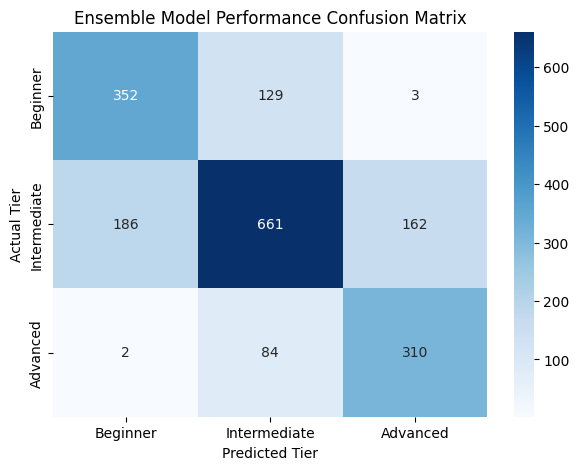

In [ ]:
prob_xgb = xgb_clf.predict_proba(X_test_combined)
prob_rf = rf_clf.predict_proba(X_test_combined)
prob_mlp = late_fusion_model.predict([X_sem_test_raw, X_struct_test_scaled])

# Blended distribution (45% XGBoost, 15% Random Forest, 40% Neural Network)
ensemble_probs = (0.45 * prob_xgb) + (0.15 * prob_rf) + (0.40 * prob_mlp)
y_pred_ensemble = np.argmax(ensemble_probs, axis=-1)

print("\n--- TRIPLE-STACK SOFT ENSEMBLE CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_ensemble, target_names=['Beginner', 'Intermediate', 'Advanced']))

# Generate and plot confusion matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_ensemble)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Beginner', 'Intermediate', 'Advanced'],
            yticklabels=['Beginner', 'Intermediate', 'Advanced'])
plt.xlabel('Predicted Tier')
plt.ylabel('Actual Tier')
plt.title('Ensemble Model Performance Confusion Matrix')
plt.show()

# Part 8: Inference

In [ ]:
synonym_database = {
    "exacerbate": "worsen",
    "hypothesis": "guess",
    "metamorphosis": "change",
    "philanthropy": "charity",
    "ephemeral": "short-lived",
    "ambiguous": "unclear",
    "beautiful": "pretty"
}

def analyze_passage(passage, target_comfort_level=1):
    """
    Parses a string text passage, tags word tokens, extracts features
    using the fitted pipeline state, and highlights difficult content terms.
    """
    words = re.findall(r'\b\w+\b', passage)
    tagged_tokens = nltk.pos_tag(words)
    results = []

    for word, tag in tagged_tokens:
        word_lower = word.lower()
        is_content = tag.startswith(('NN', 'VB', 'JJ', 'RB'))

        # 1. Pipeline transformations using fitted instances
        single_sem, single_struct = pipeline.transform_single_word(word_lower, tag)
        scaled_single_struct = struct_scaler.transform([single_struct])

        # 2. Probability extraction from all streams
        xgb_prob = xgb_clf.predict_proba(np.hstack((single_sem.reshape(1, -1), scaled_single_struct)))
        rf_prob = rf_clf.predict_proba(np.hstack((single_sem.reshape(1, -1), scaled_single_struct)))
        mlp_prob = late_fusion_model.predict([single_sem.reshape(1, -1), scaled_single_struct], verbose=0)

        # Soft voting
        fused_prob = (0.45 * xgb_prob) + (0.15 * rf_prob) + (0.40 * mlp_prob)
        predicted_tier = int(np.argmax(fused_prob, axis=-1)[0])

        # Flagging logic
        is_difficult = is_content and (predicted_tier > target_comfort_level)
        status = "CHALLENGING" if is_difficult else "OK"
        suggestion = synonym_database.get(word_lower, None) if is_difficult else None

        results.append({
            "word": word,
            "pos": tag,
            "predicted_tier": predicted_tier,
            "status": status,
            "suggestion": suggestion
        })

    return results


if __name__ == "__main__":
    sample_text = "Dinosaurs are a diverse group of reptiles of the clade Dinosauria. They first appeared during the Triassic period and became the dominant terrestrial vertebrates."

    print("\nExecuting live analysis for target Tier 1 (Intermediate Comfort Level)...")
    results = analyze_passage(sample_text, target_comfort_level=1)

    for item in results:
        if item['status'] == "CHALLENGING":
            print(f"[!] '{item['word']}' (Predicted Tier: {item['predicted_tier']})")
            if item['suggestion']:
                print(f"    ↳ Simplification suggestion: '{item['suggestion']}'")
        else:
            print(f"    '{item['word']}'")


Executing live analysis for target Tier 1 (Intermediate Comfort Level)...
[!] 'Dinosaurs' (Predicted Tier: 2)
    'are'
    'a'
    'diverse'
    'group'
    'of'
[!] 'reptiles' (Predicted Tier: 2)
    'of'
    'the'
[!] 'clade' (Predicted Tier: 2)
[!] 'Dinosauria' (Predicted Tier: 2)
    'They'
    'first'
[!] 'appeared' (Predicted Tier: 2)
    'during'
    'the'
[!] 'Triassic' (Predicted Tier: 2)
    'period'
    'and'
[!] 'became' (Predicted Tier: 2)
    'the'
[!] 'dominant' (Predicted Tier: 2)
[!] 'terrestrial' (Predicted Tier: 2)
[!] 'vertebrates' (Predicted Tier: 2)


# **Part 9: Part 8 Improved**

This module dynamically queries WordNet for POS-aligned synonym candidates, grades their complexity using the trained XGBoost, Random Forest, and MLP ensemble, and ranks them to select the most pedagogically appropriate simplification.

In [ ]:
!pip install groq

In [ ]:
import types

def patched_transform_single_word(self, word, tag='NN'):
    """
    Patches the feature extraction class to resolve base lemmas BEFORE
    querying the frequency dictionary, ensuring inflected verbs (became, appeared)
    and plural nouns get their true high-frequency classifications.
    """
    word_lower = str(word).lower()

    # WordNet POS mapping
    pos_char = 'n'
    if tag.startswith('JJ'): pos_char = 'a'
    elif tag.startswith('RB'): pos_char = 'r'
    elif tag.startswith('VB'): pos_char = 'v'
    elif tag.startswith('NN'): pos_char = 'n'

    # Resolve the base lemma of the inflected word
    orig_lemma = self.lemmatizer.lemmatize(word_lower, pos_char)

    # Secure frequency lookup using the base lemma, fallback to raw word if needed
    freq_val = self.frequency_dict.get(orig_lemma, 0.0)
    if freq_val == 0.0 and orig_lemma != word_lower:
        freq_val = self.frequency_dict.get(word_lower, 0.0)

    raw_struct = self._extract_raw_structural(word_lower, tag, freq_val)

    if self.is_fitted:
        scaled_struct = self.scaler.transform([raw_struct])
        cluster_id = self.kmeans.predict(scaled_struct)[0]
        cluster_onehot = [0] * self.n_clusters
        cluster_onehot[cluster_id] = 1
        final_struct = raw_struct + cluster_onehot
    else:
        cluster_onehot = [0] * self.n_clusters
        final_struct = raw_struct + cluster_onehot

    semantic_vector = self.transformer.encode(word_lower, convert_to_numpy=True)
    return semantic_vector, np.array(final_struct)

pipeline.transform_single_word = types.MethodType(patched_transform_single_word, pipeline)
print("Pipeline dynamically patched to support inflected-lemma frequency lookups.")

Pipeline dynamically patched to support inflected-lemma frequency lookups.


In [ ]:
import json
import re
from groq import Groq
from google.colab import userdata

def analyze_passage_hybrid(passage, target_comfort_level=1):
    """
    Core hybrid analyzer:
    1. Gates complexity locally using our ensemble model & syntactic parsing.
    2. Identifies adjacent target words and groups them into compound phrases BEFORE lookups.
    3. Executes a highly constrained, token-limited API call to Groq using generalized linguistic constraints.
    """
    # Step A: Run local syntactic parser and complexity gating
    doc = nlp(passage)
    protected_tokens = set()

    for token in doc:
        if token.dep_ in ['nsubj', 'nsubjpass']:
            protected_tokens.add(token.text.lower())
        if token.pos_ == 'PROPN':
            protected_tokens.add(token.text.lower())

    words = re.findall(r'\b\w+\b', passage)
    tagged_tokens = nltk.pos_tag(words)
    local_results = []
    challenging_indices = []

    # Perform local complexity profiling on all tokens
    for idx, (word, tag) in enumerate(tagged_tokens):
        word_lower = word.lower()
        is_content = tag.startswith(('NN', 'VB', 'JJ', 'RB'))

        is_subject = word_lower in protected_tokens
        is_mid_sentence_capitalized = (idx > 0) and word[0].isupper()
        is_proper_noun_tag = tag in ['NNP', 'NNPS']
        is_protected = is_subject or is_mid_sentence_capitalized or is_proper_noun_tag

        single_sem, single_struct = pipeline.transform_single_word(word_lower, tag)
        scaled_single_struct = struct_scaler.transform([single_struct])
        combined_features = np.hstack((single_sem.reshape(1, -1), scaled_single_struct))

        xgb_prob = xgb_clf.predict_proba(combined_features)
        rf_prob = rf_clf.predict_proba(combined_features)
        mlp_prob = late_fusion_model.predict([single_sem.reshape(1, -1), scaled_single_struct], verbose=0)

        fused_prob = (0.45 * xgb_prob) + (0.15 * rf_prob) + (0.40 * mlp_prob)
        predicted_tier = int(np.argmax(fused_prob, axis=-1)[0])

        # Gate: Flag difficult common content words
        is_difficult = is_content and not is_protected and (predicted_tier > target_comfort_level)
        is_advanced_proper_noun = is_proper_noun_tag and (predicted_tier > target_comfort_level)
        is_tricky_verb = tag.startswith('VB') and is_difficult

        local_results.append({
            "word": word,
            "pos": tag,
            "predicted_tier": predicted_tier,
            "status": "OK",
            "suggestion": None,
            "is_protected": is_protected
        })

        # Collect any index that meets our difficulty criteria
        if is_difficult or is_advanced_proper_noun or is_tricky_verb:
            challenging_indices.append(idx)

    # Step B: Group adjacent challenging indices into unified chunks (Consolidation First)
    chunks = []
    if challenging_indices:
        current_chunk = [challenging_indices[0]]
        for idx in challenging_indices[1:]:
            if idx - current_chunk[-1] == 1:
                current_chunk.append(idx)
            else:
                chunks.append(current_chunk)
                current_chunk = [idx]
        chunks.append(current_chunk)

    # Construct phrases and compile the payload for Groq
    phrases_requiring_llm = []
    for chunk in chunks:
        chunk_words = [local_results[i]['word'] for i in chunk]
        phrase = " ".join(chunk_words)
        pos_tags = ", ".join([local_results[i]['pos'] for i in chunk])
        max_predicted_tier = max([local_results[i]['predicted_tier'] for i in chunk])

        first_idx = chunk[0]
        last_idx = chunk[-1]
        preceding_context = words[first_idx - 1] if first_idx > 0 else ""
        following_context = words[last_idx + 1] if last_idx < len(words) - 1 else ""

        phrases_requiring_llm.append({
            "phrase": phrase,
            "pos_tags": pos_tags,
            "preceding_context": preceding_context,
            "following_context": following_context,
            "predicted_tier": max_predicted_tier,
            "indices": chunk
        })

    # Step C: Execute batch completion via Groq
    from google.colab import userdata
    groq_api_key = userdata.get("groqAPI")

    if not phrases_requiring_llm or not groq_api_key:
        if not groq_api_key and phrases_requiring_llm:
            print("Notice: 'groqAPI' key not found in environment. Falling back to local pipeline.")
        return local_results

    client = Groq(api_key=groq_api_key)

    # Remove internal indices tracking from payload sent to Groq to save token context
    groq_payload = [
        {
            "phrase": p["phrase"],
            "pos_tags": p["pos_tags"],
            "preceding_context": p["preceding_context"],
            "following_context": p["following_context"],
            "predicted_tier": p["predicted_tier"]
        }
        for p in phrases_requiring_llm
    ]

    # Generalized, abstract linguistic system prompt
    prompt = f"""
    Original Passage: "{passage}"

    The following words or compound phrases inside the passage are too complex for a Reader at comfort level Tier {target_comfort_level}.
    For each target phrase, provide a simpler, context-appropriate, grammatically matching synonym or short phrase (MAXIMUM of 2 words) that fits seamlessly in the sentence.

    CRITICAL SYNTACTIC & STYLE RULES:
    1. SYNTACTIC CONGRUENCE: Ensure that the suggested replacement is 100% grammatically compatible with BOTH the provided `preceding_context` and `following_context`.
       - If the target is an adjective preceded by a singular indefinite article (such as 'a' or 'an'), do not output plural quantifiers or phrases that violate singular determiner agreement.
       - The replacement must slot directly into the sentence structure without requiring any surrounding words to be modified.
    2. GRAMMATICAL EQUIVALENCY: The suggestion must match the target's exact part-of-speech, grammatical number (singular/plural), tense, and aspect (e.g., past-tense verbs must map to past-tense replacements).
    3. TONAL CONGRUENCE: The suggested synonym must maintain a standard, mature, and professional-yet-accessible tone suitable for informative, educational, or academic text.
       - Avoid overly childish, slangy, or highly informal words (e.g., prefer standard verb phrases over highly colloquial verbs, and neutral historical or scientific descriptors over informal slang).
       - For scientific proper nouns, provide a simplified, mature classification or general equivalent (MAXIMUM of 2 words).

    Target Phrases:
    {json.dumps(groq_payload, indent=2)}

    Output a raw JSON object ONLY, mapping the original target "phrase" to the simpler suggestion. Do not include markdown formatting or chat text.
    Example format:
    {{
      "original target phrase 1": "simplified replacement 1",
      "original target phrase 2": "simplified replacement 2"
    }}
    """

    # Using llama-3.3-70b-versatile with strict max_token constraints (150) to force conciseness
    chat_completion = client.chat.completions.create(
        messages=[
            {"role": "system", "content": "You are a precise lexical simplification API. You only output raw JSON, with no explanations or formatting. Keep every suggestion strictly to a maximum of 2 words. Adhere strictly to the professional tone rules in the prompt."},
            {"role": "user", "content": prompt}
        ],
        model="llama-3.3-70b-versatile",
        temperature=0.1,
        max_tokens=150
    )

    response_text = chat_completion.choices[0].message.content.strip()

    if response_text.startswith("```"):
        response_text = re.sub(r"^```(?:json)?\n", "", response_text)
        response_text = re.sub(r"\n```$", "", response_text)

    try:
        simplification_map = json.loads(response_text)
    except Exception as e:
        print(f"Error parsing Groq JSON: {e}. Raw response: {response_text}")
        simplification_map = {}

    # Step E: Merge LLM recommendations back into our results (with multi-word phrase protection)
    for item in phrases_requiring_llm:
        phrase = item['phrase']
        indices = item['indices']
        phrase_lower = phrase.lower()

        suggestion = None
        if phrase in simplification_map:
            suggestion = simplification_map[phrase]
        elif phrase_lower in simplification_map:
            suggestion = simplification_map[phrase_lower]

        if suggestion:
            # Write suggestion to first index of the chunk
            first_idx = indices[0]
            local_results[first_idx]['status'] = "CHALLENGING"
            local_results[first_idx]['suggestion'] = suggestion

            # Label remaining indexes in chunk as merged to bypass duplicate printing
            for other_idx in indices[1:]:
                local_results[other_idx]['status'] = "MERGED"
                local_results[other_idx]['suggestion'] = ""

    return local_results


In [ ]:
if __name__ == "__main__":
    sample_text = (
        "Dinosaurs are a diverse group of reptiles of the clade Dinosauria. "
        "They first appeared during the Triassic period and became the dominant "
        "terrestrial vertebrates."
    )

    print("\nExecuting live HYBRID analysis for target Tier 0...")
    results = analyze_passage_hybrid(sample_text, target_comfort_level=0)

    for item in results:
        if item['status'] == "CHALLENGING":
            print(f"[!] '{item['word']}' (Predicted Tier: {item['predicted_tier']})")
            if item['suggestion']:
                print(f"    ↳ Hybrid Simplification suggested: '{item['suggestion']}'")
            else:
                print(f"    ↳ No simpler POS-aligned alternative found.")
        elif item['status'] == "MERGED":
            continue
        else:
            print(f"    '{item['word']}'")


Executing live HYBRID analysis for target Tier 0...
    'Dinosaurs'
    'are'
    'a'
[!] 'diverse' (Predicted Tier: 1)
    ↳ Hybrid Simplification suggested: 'many'
    'group'
    'of'
[!] 'reptiles' (Predicted Tier: 2)
    ↳ Hybrid Simplification suggested: 'animals'
    'of'
    'the'
[!] 'clade' (Predicted Tier: 2)
    ↳ Hybrid Simplification suggested: 'dino group'
    'They'
    'first'
[!] 'appeared' (Predicted Tier: 1)
    ↳ Hybrid Simplification suggested: 'came'
    'during'
    'the'
[!] 'Triassic' (Predicted Tier: 2)
    ↳ Hybrid Simplification suggested: 'old time'
    'period'
    'and'
[!] 'became' (Predicted Tier: 1)
    ↳ Hybrid Simplification suggested: 'were'
    'the'
[!] 'dominant' (Predicted Tier: 2)
    ↳ Hybrid Simplification suggested: 'main animals'


In [ ]:
print(results)

[{'word': 'Dinosaurs', 'pos': 'NNS', 'predicted_tier': 1, 'status': 'OK', 'suggestion': None, 'is_protected': True}, {'word': 'are', 'pos': 'VBP', 'predicted_tier': 0, 'status': 'OK', 'suggestion': None, 'is_protected': False}, {'word': 'a', 'pos': 'DT', 'predicted_tier': 0, 'status': 'OK', 'suggestion': None, 'is_protected': False}, {'word': 'diverse', 'pos': 'JJ', 'predicted_tier': 1, 'status': 'CHALLENGING', 'suggestion': 'many', 'is_protected': False}, {'word': 'group', 'pos': 'NN', 'predicted_tier': 0, 'status': 'OK', 'suggestion': None, 'is_protected': False}, {'word': 'of', 'pos': 'IN', 'predicted_tier': 0, 'status': 'OK', 'suggestion': None, 'is_protected': False}, {'word': 'reptiles', 'pos': 'NNS', 'predicted_tier': 2, 'status': 'CHALLENGING', 'suggestion': 'animals', 'is_protected': False}, {'word': 'of', 'pos': 'IN', 'predicted_tier': 0, 'status': 'OK', 'suggestion': None, 'is_protected': False}, {'word': 'the', 'pos': 'DT', 'predicted_tier': 0, 'status': 'OK', 'suggestion':